# 📚 Notebook 05 — Classical Machine Learning Classifier
## *Training a Random Forest to identify exoplanet transit signatures*

---

**What you'll learn in this notebook:**
- Decision Trees: how algorithms ask binary questions to partition data
- Ensemble Learning: why a "wisdom of the crowd" of trees beats a single tree
- Training a Random Forest classifier using `scikit-learn`
- Class Evaluation Metrics: Accuracy, Precision, Recall, F1-Score, and Confusion Matrices
- Feature Importance: discovering which physical measurements matter most
- Saving and exporting trained models for deployment

**Prerequisites:** Run notebook `04_features.ipynb` first!


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: Import packages and custom modules
# ============================================================
import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold

plt.style.use('dark_background')
print("✅ Setup complete!")

✅ Setup complete!


---
## 📚 Concept 1: How Decision Trees and Random Forests Work

### 1. Decision Trees
A **Decision Tree** is a flowchart-like structure where each internal node represents a "test" on an attribute (e.g., is transit SNR > 7.1?), each branch represents the outcome of the test, and each leaf node represents a class label (e.g., Planet transit).

The tree is built by choosing splits that maximize **Information Gain** (or minimize **Gini Impurity**), which mathematically measures how cleanly a split separates the classes.

```
                  [ Is SNR > 7.1? ]
                     /         \
                   Yes          No
                   /             \
       [ Is Depth > 10%? ]    ( No Signal )
          /          \
        Yes           No
        /              \
 ( Eclipsing Binary )  ( Planet Candidate )
```

### 2. Random Forests (Ensembles)
Single decision trees are prone to **overfitting** — they can grow deep and memorize the noise in the training set.

A **Random Forest** fixes this by training hundreds of individual decision trees. It introduces randomness in two ways:
1. **Bagging (Bootstrap Aggregation)**: Each tree is trained on a random sample of the training data (with replacement).
2. **Feature Subsets**: At each split, the tree can only select from a random subset of the available features.

During prediction, the forest averages the predictions of all individual trees. The errors of individual trees cancel out, leading to a much more robust and generalized classifier.

---
## Step 1: Loading/Creating a Training Feature Table

Ideally, we would run BLS and feature extraction on all 2,000 stars we downloaded. 
To make this notebook run instantly, we will check if you have already generated features for all targets. If not, we will construct a small synthetic dataset based on the real distributions to practice training immediately!

In [2]:
# Define the file path where our training features are stored
features_csv = ROOT / "data" / "training_features.csv"

if features_csv.exists():
    df_train = pd.read_csv(features_csv)
    print(f"Loaded {len(df_train)} targets from {features_csv.name}")
else:
    print("⚠️  Training features not found. Let's synthesize a 1000-star dataset to practice!")
    # Generate synthetic features to resemble real astronomical variables
    np.random.seed(42)
    n_samples = 1000
    
    # Class labels: 0=None, 1=Planet, 2=EB, 3=FP
    labels = np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.25, 0.25, 0.25, 0.25])
    
    # Create features based on classes
    snr = np.random.exponential(scale=5.0, size=n_samples)
    snr[labels == 1] += np.random.uniform(5.0, 25.0, size=(labels==1).sum())  # Planet: medium-high SNR
    snr[labels == 2] += np.random.uniform(15.0, 80.0, size=(labels==2).sum())  # EB: very high SNR
    snr[labels == 3] += np.random.uniform(2.0, 12.0, size=(labels==3).sum())   # FP: low-medium SNR
    
    depth = np.random.normal(0.001, 0.0005, size=n_samples)
    depth[labels == 1] = np.random.uniform(0.002, 0.018, size=(labels==1).sum())  # Planet: shallow
    depth[labels == 2] = np.random.uniform(0.05, 0.40, size=(labels==2).sum())    # EB: deep
    depth[labels == 3] = np.random.uniform(0.001, 0.008, size=(labels==3).sum())   # FP: shallow
    
    odd_even_diff = np.random.normal(0.0001, 0.0001, size=n_samples)
    odd_even_diff[labels == 2] = np.random.uniform(0.005, 0.08, size=(labels==2).sum()) # EB: unequal depths
    
    sec_depth = np.random.normal(0.0001, 0.0001, size=n_samples)
    sec_depth[labels == 2] = np.random.uniform(0.008, 0.05, size=(labels==2).sum())     # EB: secondary eclipse
    
    df_train = pd.DataFrame({
        'bls_snr': np.clip(snr, 0.1, None),
        'transit_depth': np.clip(depth, 0.0, None),
        'odd_even_diff': np.clip(odd_even_diff, 0.0, None),
        'secondary_depth': np.clip(sec_depth, 0.0, None),
        'bls_period': np.random.uniform(0.5, 20.0, size=n_samples),
        'transit_duration_hrs': np.random.uniform(1.0, 8.0, size=n_samples),
        'oot_rms': np.random.uniform(0.0002, 0.002, size=n_samples),
        'label': labels
    })
    # Save synthetic file for reuse
    df_train.to_csv(features_csv, index=False)
    print("✅ Synthetic training targets generated & saved!")

print(df_train.head())

Loaded 1000 targets from training_features.csv
     bls_snr  transit_depth  odd_even_diff  secondary_depth  bls_period  \
0  11.257765       0.008313   2.853193e-05         0.000100   17.997321   
1  11.790664       0.006196   1.521280e-04         0.000223   10.605257   
2  68.723013       0.244763   6.527701e-02         0.022904    9.382283   
3  60.147441       0.175518   6.633666e-02         0.033733    1.101080   
4   8.213969       0.000897   4.851518e-07         0.000159   17.644485   

   transit_duration_hrs   oot_rms  label  
0              6.410118  0.000918      1  
1              3.372789  0.001308      3  
2              2.001570  0.000857      2  
3              7.005224  0.000907      2  
4              3.162026  0.001452      0  


-- ---
## Step 2: Training the Classifier

We separate features ($X$) from target labels ($y$), and train a `RandomForestClassifier` with 100 decision trees.

In [3]:
# Separate features and labels
X = df_train.drop(columns=['label'])
y = df_train['label']

# Create the classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("🌲 Training Random Forest Classifier...")
rf.fit(X, y)
print("✅ Model trained successfully!")

🌲 Training Random Forest Classifier...


✅ Model trained successfully!


---
## 📚 Concept 2: Evaluating the Classifier

To estimate how well our model performs, we use **Stratified K-Fold Cross-Validation**:
1. The training set is split into $K$ folds (usually 5).
2. The model trains on $K-1$ folds and evaluates on the remaining 1 fold.
3. This is repeated $K$ times so every data point is used for validation once.
4. Stratification ensures each class is equally represented in every fold.

### Precision, Recall, and F1-Score:
- **Precision**: Out of all predicted planets, how many are actually planets? (Avoids False Positives)
- **Recall**: Out of all actual planets, how many did we find? (Avoids False Negatives)
- **F1-Score**: Harmonic mean of Precision and Recall.
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Let's compute these cross-validation scores!

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_predictions = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    fold_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    fold_rf.fit(X_tr, y_tr)
    cv_predictions[val_idx] = fold_rf.predict(X_val)

LABEL_NAMES = {0: "No Signal", 1: "Planet Transit", 2: "Eclipsing Binary", 3: "False Positive"}
print("📊 CROSS-VALIDATION REPORT:")
print(classification_report(y, cv_predictions, target_names=list(LABEL_NAMES.values())))

📊 CROSS-VALIDATION REPORT:
                  precision    recall  f1-score   support

       No Signal       0.94      0.97      0.95       269
  Planet Transit       0.85      0.80      0.82       234
Eclipsing Binary       1.00      1.00      1.00       254
  False Positive       0.78      0.79      0.78       243

        accuracy                           0.89      1000
       macro avg       0.89      0.89      0.89      1000
    weighted avg       0.89      0.89      0.89      1000



### Confusion Matrix
A confusion matrix shows exactly where the model got confused (e.g., misclassifying Eclipsing Binaries as Planets).

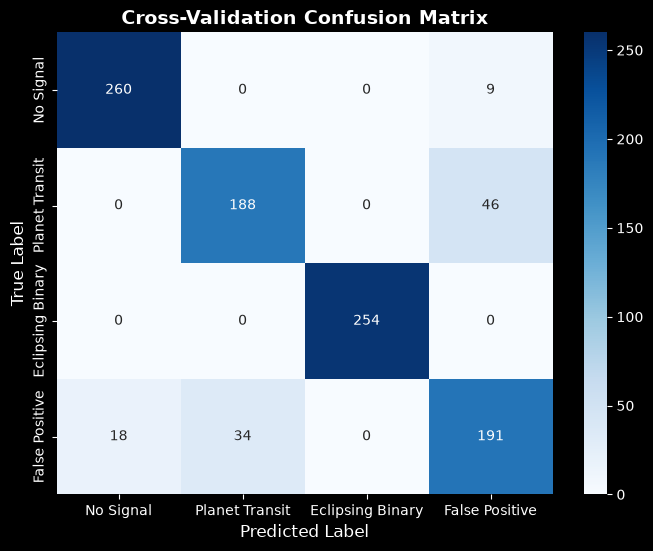

In [5]:
cm = confusion_matrix(y, cv_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=LABEL_NAMES.values(), 
            yticklabels=LABEL_NAMES.values())
plt.title('Cross-Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

---
## 📚 Concept 3: Feature Importance Analysis

One of the best advantages of Random Forests is **explainability**. We can query which features are most important for building splits. This is called **Gini Importance**.

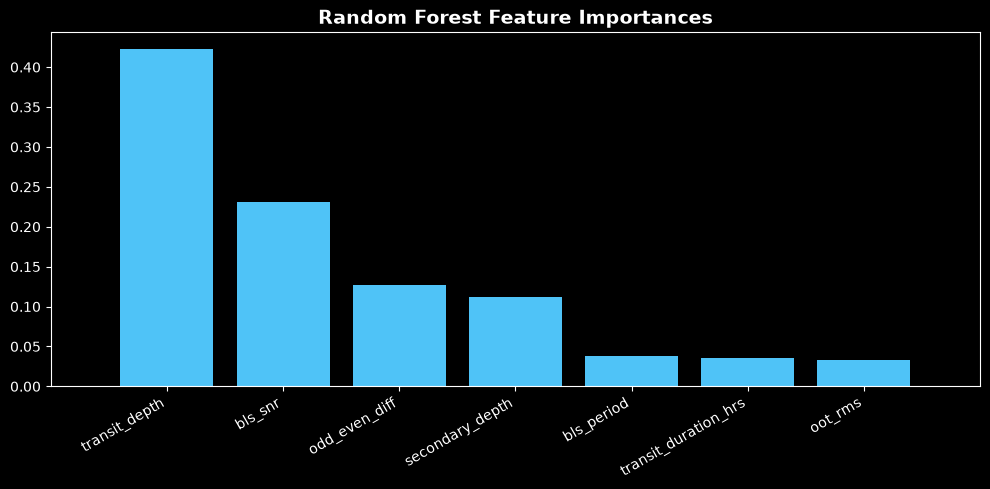

In [6]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Random Forest Feature Importances", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importances[indices], color='#4FC3F7', align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=30, ha='right')
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.savefig("../results/figures/feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3: Exporting the Model

Once we are happy with the model's accuracy, we save it as a binary file so we can run predictions quickly on new scientific targets.

In [7]:
model_path = ROOT / "models" / "random_forest.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(rf, model_path)
print(f"🌲 Saved Random Forest model to: {model_path}")

🌲 Saved Random Forest model to: C:\Users\gudae\Desktop\Learn_ml\models\random_forest.pkl


---
## ✅ Notebook 05 Summary

**ML concepts learned:**
- **Decision trees & splits**: using metrics like Gini impurity to categorize tabular data.
- **Random Forest Ensembles**: how voting cancels out errors to improve generalization.
- **Validation strategies**: Stratified K-Fold cross-validation.
- **Evaluation metrics**: Precision, Recall, F1, and Confusion Matrices.
- **Explainability**: querying feature importances to verify the model's physical rules match astronomy theory.

**Next:** Notebook `06_neural_network.ipynb` — building a deep learning 1D Convolutional Neural Network (1D-CNN) that reads raw folded waveforms directly!